In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

**Load mixed data**

In [14]:
stiffness_tag = "1000"
base_dir = "logs"

log_dir = os.path.join(base_dir, stiffness_tag)

ref_data = pd.read_csv('cartesian_ref_xyz1.csv')
ref_data_x = ref_data["x"]
ref_data_y = ref_data["y"]
ref_data_z = ref_data["z"]

t_common = ref_data['time_s'].to_numpy()

ref_x = ref_data_x.to_numpy()
ref_y = ref_data_y.to_numpy()
ref_z = ref_data_z.to_numpy()

xyz_ref = np.stack([ref_x, ref_y, ref_z], axis=1)
xyz_data = pd.read_csv(os.path.join(log_dir, "cartesian_log_xyz1.csv"))[["x", "y", "z"]].to_numpy()
xyz_kernel = pd.read_csv(os.path.join(log_dir, "cartesian_log_kernel_xyz1.csv"))[["x", "y", "z"]].to_numpy()

N = min(len(t_common), len(xyz_data), len(xyz_kernel), len(ref_x), len(ref_y), len(ref_z))

xyz_ref = xyz_ref[:N]
xyz_data = xyz_data[:N]
xyz_kernel = xyz_kernel[:N]

err_no_comp_xyz = xyz_data - xyz_ref
err_comp_xyz = xyz_kernel - xyz_ref

print(xyz_ref.shape)

(64994, 3)


**Plots**

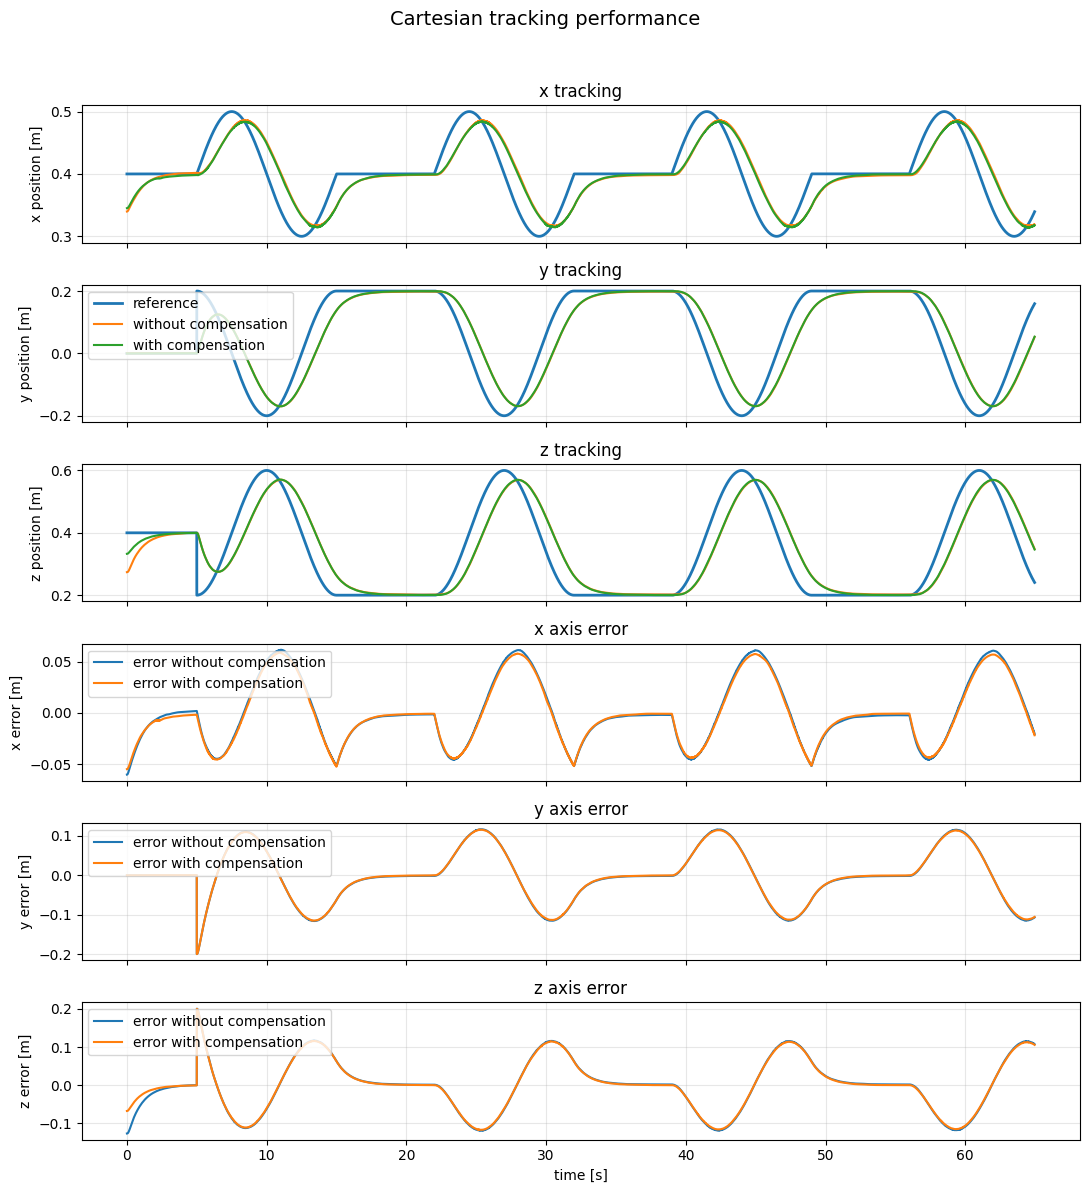

In [5]:
labels = ["x", "y", "z"]
units = "position [m]"

fig, axes = plt.subplots(6, 1, figsize=(11, 12), sharex=True)

# x, y, z tracking (axes 0,1,2)
for i, ax in enumerate(axes[:3]):
    ax.plot(t_common[:N], xyz_ref[:, i], label="reference", linewidth=2)
    ax.plot(t_common[:N], xyz_data[:, i], label="without compensation", linewidth=1.5)
    ax.plot(t_common[:N], xyz_kernel[:, i], label="with compensation", linewidth=1.5)
    ax.set_ylabel(f"{labels[i]} {units}")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{labels[i]} tracking")

# x, y, z errors (axes 3,4,5)
for i, ax in enumerate(axes[3:6]):
    ax.plot(t_common[:N], err_no_comp_xyz[:, i], label="error without compensation", linewidth=1.5)
    ax.plot(t_common[:N], err_comp_xyz[:, i], label="error with compensation", linewidth=1.5)
    ax.set_ylabel(f"{labels[i]} error [m]")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{labels[i]} axis error")
    ax.legend(loc="upper left")

axes[1].legend(loc="upper left")
axes[-1].set_xlabel("time [s]")

fig.suptitle("Cartesian tracking performance", fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Plot precise error (mixed)**

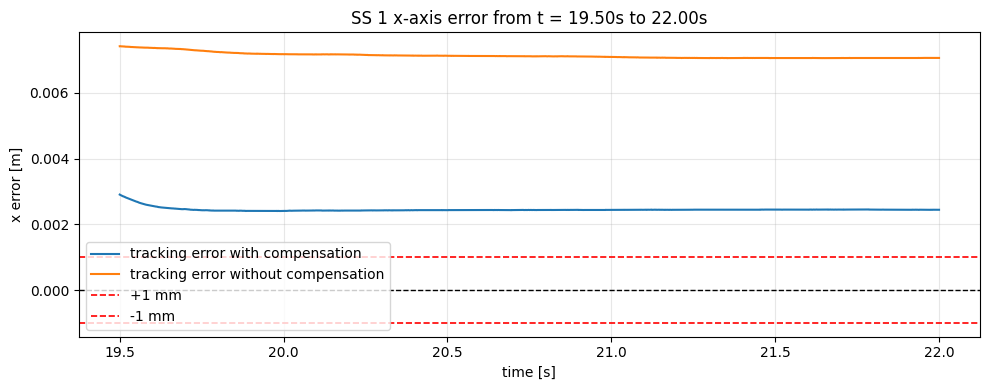

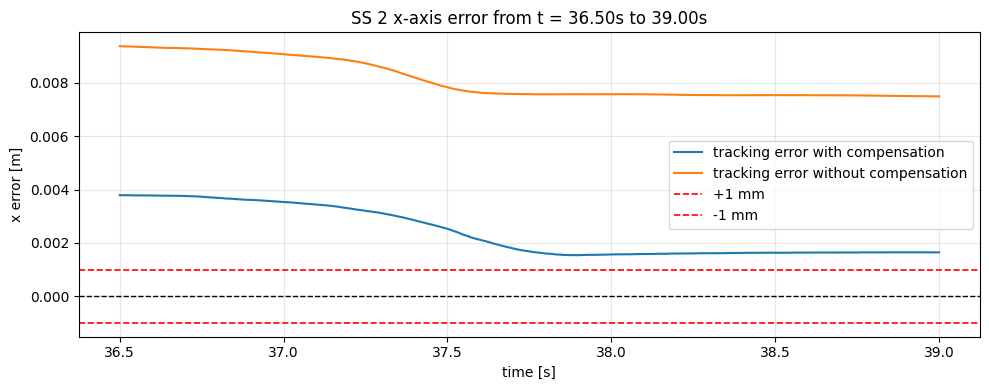

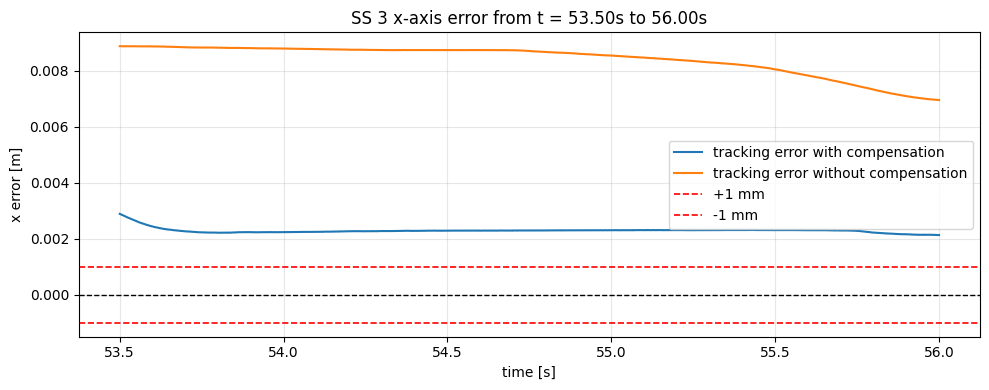

=== Steady-state x-axis error statistics ===
No compensation : mean = 7.885 mm, RMS = 7.921 mm
With compensation: mean = 2.373 mm, RMS = 2.430 mm


In [13]:

# Steady-state error analysis for x-axis
steady_state_regions = [
    (19500, 22001), # region 1
    (36500, 39001), # region 2
    (53500, 56001), # region 3
]

labels = [f"SS {i+1}" for i in range(len(steady_state_regions))]

err_ss_no_comp = []
err_ss_comp = []

for idx, (start, end) in enumerate(steady_state_regions):
    # Safety: clip to valid range
    start = max(0, start)
    end = min(len(t_common), end)

    # Extract window
    t_window = t_common[start:end]
    err_window_comp = err_comp_xyz[start:end, 2] # x-axis error
    err_window = err_no_comp_xyz[start:end, 2] # x-axis error

    err_ss_no_comp.append(err_window)
    err_ss_comp.append(err_window_comp)

    # Plot error with compensation

    plt.figure(figsize=(10, 4))
    plt.plot(t_window, err_window_comp, linewidth=1.5, label="tracking error with compensation")
    plt.plot(t_window, err_window, linewidth=1.5, label="tracking error without compensation")

    # Zero line
    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    # +- 1 mm thresholds
    plt.axhline(0.001, color='red', linestyle='--', linewidth=1.2, label="+1 mm")
    plt.axhline(-0.001, color='red', linestyle='--', linewidth=1.2, label="-1 mm")

    plt.title(f"{labels[idx]} x-axis error from t = {t_window[0]:.2f}s to {t_window[-1]:.2f}s")
    plt.xlabel("time [s]")
    plt.ylabel("x error [m]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Concatenate all steady-state samples
err_ss_no_comp = np.concatenate(err_ss_no_comp)
err_ss_comp = np.concatenate(err_ss_comp)

# Mean steady-state error
mean_no_comp = np.mean(err_ss_no_comp)
mean_comp = np.mean(err_ss_comp)

# RMS steady-state error
rms_no_comp = np.sqrt(np.mean(err_ss_no_comp**2))
rms_comp = np.sqrt(np.mean(err_ss_comp**2))

print("=== Steady-state x-axis error statistics ===")
print(f"No compensation : mean = {mean_no_comp*1000:.3f} mm, RMS = {rms_no_comp*1000:.3f} mm")
print(f"With compensation: mean = {mean_comp*1000:.3f} mm, RMS = {rms_comp*1000:.3f} mm")



**Load predictions**

In [32]:
# Load data
data = pd.read_csv(os.path.join(log_dir, "cartesian_log_kernel_xyz.csv"))
tau_ext = data.filter(like="tau_ext_").to_numpy()[1:, :] # shape (T, 7)
predictions = data.filter(like="friction_pred_").to_numpy()[1:, :] # shape (T, 7)

print("tau_ext shape:", tau_ext.shape)
print("predictions shape:", predictions.shape)

tau_ext shape: (64970, 7)
predictions shape: (64970, 7)


**Compare predictions to actual value**

Joint 0: RMSE = 0.1290 Nm
Joint 1: RMSE = 0.4058 Nm
Joint 2: RMSE = 0.1117 Nm
Joint 3: RMSE = 0.2885 Nm
Joint 4: RMSE = 0.0236 Nm
Joint 5: RMSE = 0.1305 Nm
Joint 6: RMSE = 0.0053 Nm


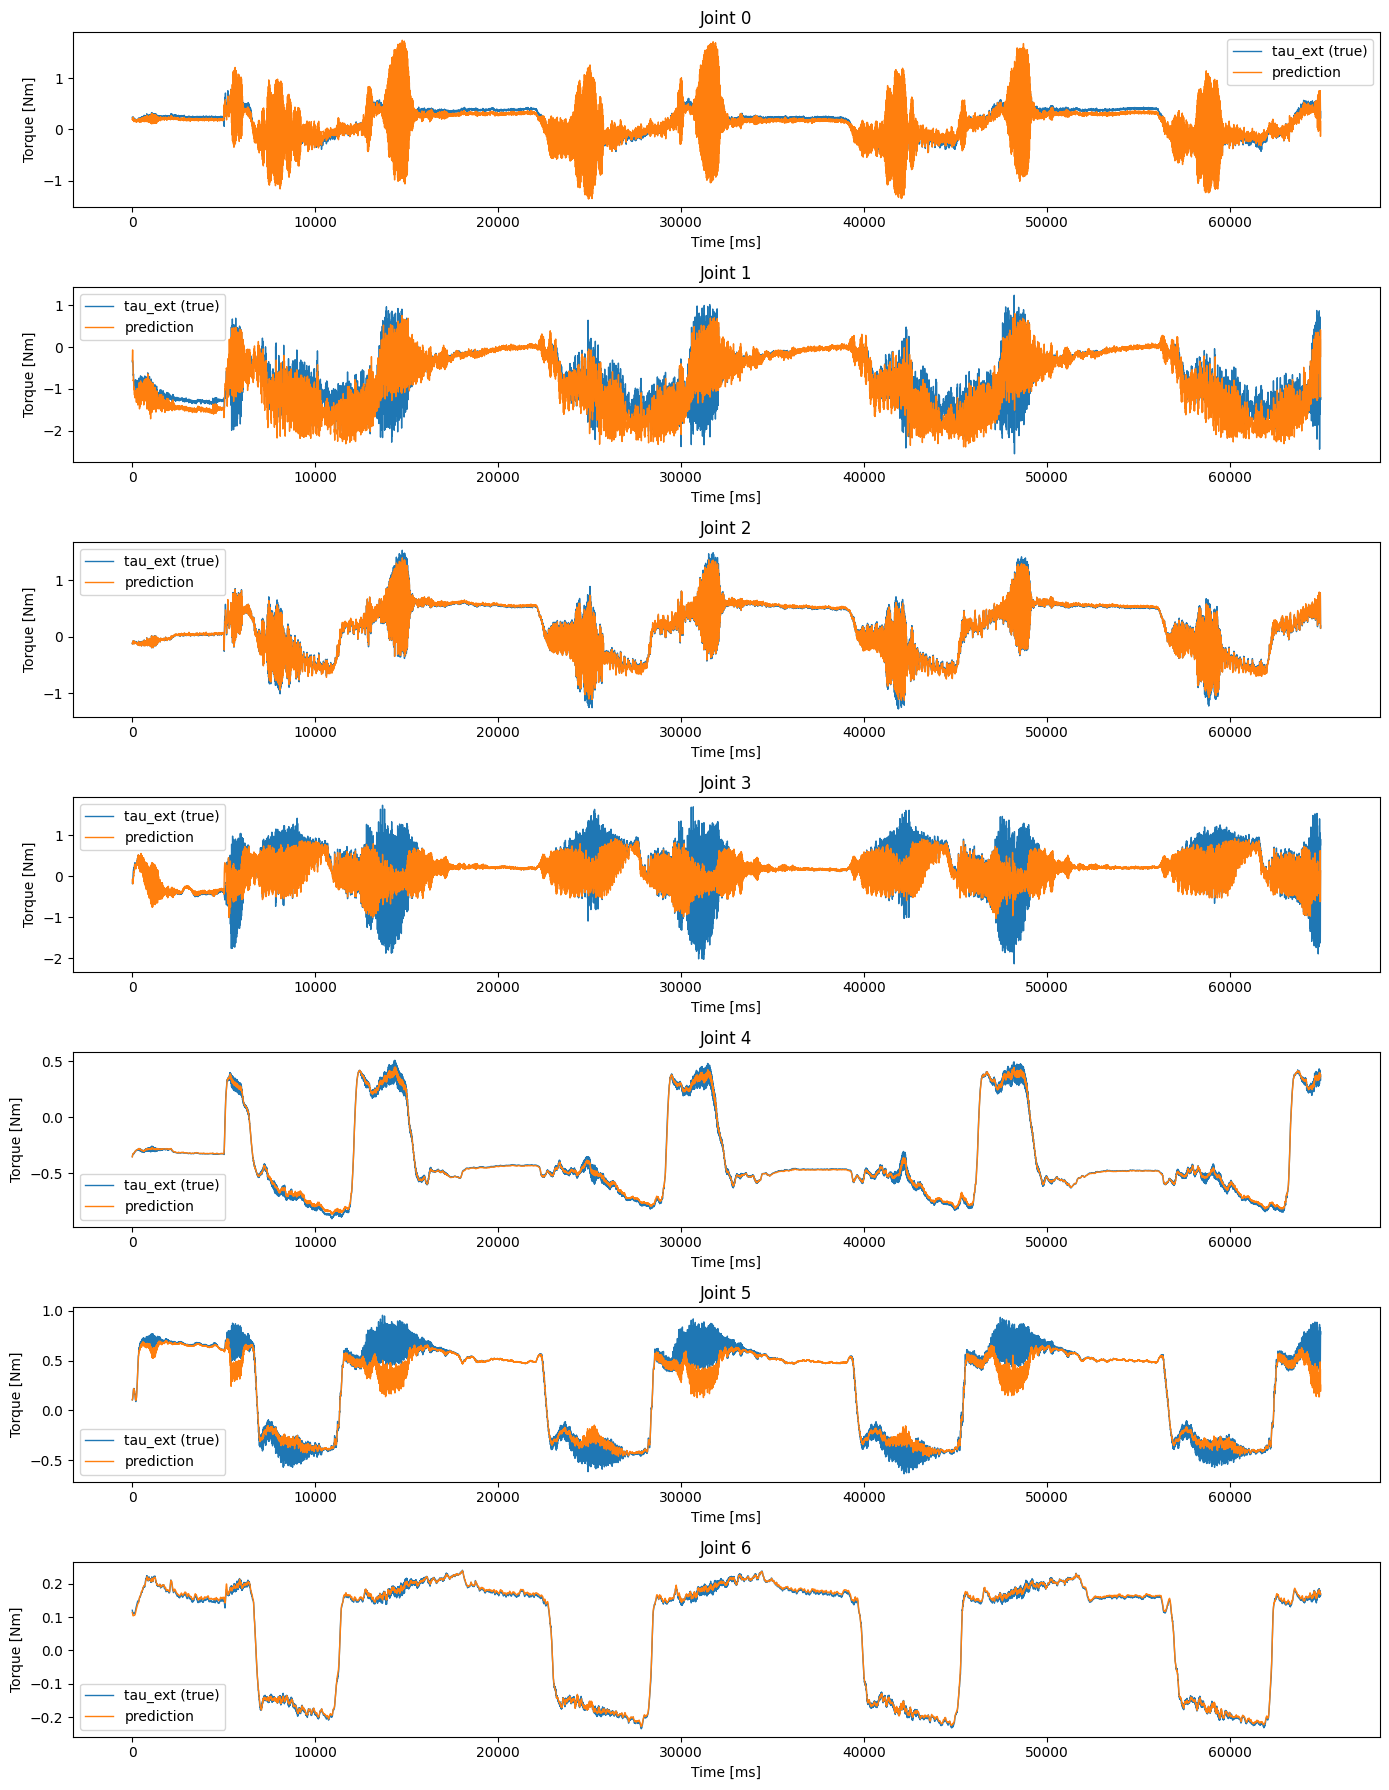

In [33]:
num_joints = tau_ext.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):

    err = tau_ext[:, i] - predictions[:, i]
    rmse = np.sqrt(np.mean(err**2))
    print(f"Joint {i}: RMSE = {rmse:.4f} Nm")
    
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(tau_ext[:, i], label="tau_ext (true)", linewidth=1.0)
    plt.plot(predictions[:, i], label="prediction", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time [ms]")
    plt.ylabel("Torque [Nm]")
    plt.legend()

plt.tight_layout()
plt.show()

**Steady-state errors (averaged over 3 trajectories)**

In [2]:
stiffness_tag = "3000"
base_dir = "logs"
traj_ids = [1, 2, 3]

# axis selection: 0=x, 1=y, 2=z
axis_idx = 0
axis_name = ["x", "y", "z"][axis_idx]

# steady-state regions
steady_state_regions = [
    (19500, 22001), # region 1
    (36500, 39001), # region 2
    # (53500, 56001), # region 3
]

# Plot per steady-state window
plot_windows = False # set False to print only the final stats

# thresholds in meters (for plotting)
thr_m = 0.001  # 1 mm

log_dir = os.path.join(base_dir, stiffness_tag)

err_ss_no_comp = []
err_ss_comp = []

# Loop trajectories
for traj_id in traj_ids:
    ref_path = f"cartesian_ref_xyz{traj_id}.csv"
    log_path = os.path.join(log_dir, f"cartesian_log_xyz{traj_id}.csv")
    ker_path = os.path.join(log_dir, f"cartesian_log_kernel_xyz{traj_id}.csv")

    # Load reference
    ref_data = pd.read_csv(ref_path)
    if not all(c in ref_data.columns for c in ["time_s", "x", "y", "z"]):
        raise ValueError(f"{ref_path} must contain columns time_s, x, y, z. Got: {list(ref_data.columns)}")

    t_common = ref_data["time_s"].to_numpy()
    xyz_ref = ref_data[["x", "y", "z"]].to_numpy()

    # Load logs
    xyz_data = pd.read_csv(log_path)[["x", "y", "z"]].to_numpy()
    xyz_kernel = pd.read_csv(ker_path)[["x", "y", "z"]].to_numpy()

    # Align lengths
    N = min(len(t_common), len(xyz_ref), len(xyz_data), len(xyz_kernel))
    t_common = t_common[:N]
    xyz_ref = xyz_ref[:N]
    xyz_data = xyz_data[:N]
    xyz_kernel = xyz_kernel[:N]

    # Errors (measured - reference)
    err_no_comp_xyz = xyz_data - xyz_ref
    err_comp_xyz = xyz_kernel - xyz_ref

    labels = [f"SS {i+1}" for i in range(len(steady_state_regions))]

    # Loop steady-state windows
    for idx, (start, end) in enumerate(steady_state_regions):
        start = max(0, start)
        end = min(N, end)
        if end <= start:
            continue

        t_window = t_common[start:end]
        err_window_no = err_no_comp_xyz[start:end, axis_idx]
        err_window_co = err_comp_xyz[start:end, axis_idx]

        # accumulate for final stats
        err_ss_no_comp.append(err_window_no)
        err_ss_comp.append(err_window_co)

        # optional plots
        if plot_windows:
            plt.figure(figsize=(10, 4))
            plt.plot(t_window, err_window_co, linewidth=1.5, label="tracking error with compensation")
            plt.plot(t_window, err_window_no, linewidth=1.5, label="tracking error without compensation")

            plt.axhline(0, color="black", linestyle="--", linewidth=1)
            plt.axhline(+thr_m, color="red", linestyle="--", linewidth=1.2, label="+1 mm")
            plt.axhline(-thr_m, color="red", linestyle="--", linewidth=1.2, label="-1 mm")

            plt.title(
                f"xyz{traj_id} {labels[idx]} {axis_name}-axis error "
                f"from t = {t_window[0]:.2f}s to {t_window[-1]:.2f}s"
            )
            plt.xlabel("time [s]")
            plt.ylabel(f"{axis_name} error [m]")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

# Final statistics
if len(err_ss_no_comp) == 0 or len(err_ss_comp) == 0:
    raise RuntimeError("No steady-state samples were collected. Check your steady_state_regions indices and data length.")

err_ss_no_comp = np.concatenate(err_ss_no_comp)
err_ss_comp = np.concatenate(err_ss_comp)

mean_no_comp = np.mean(err_ss_no_comp)
mean_comp = np.mean(err_ss_comp)

rms_no_comp = np.sqrt(np.mean(err_ss_no_comp**2))
rms_comp = np.sqrt(np.mean(err_ss_comp**2))

print(f"=== Steady-state {axis_name}-axis error statistics (xyz{traj_ids[0]}-xyz{traj_ids[-1]}), stiffness={stiffness_tag} ===")
print(f"No compensation : mean = {mean_no_comp*1000:.3f} mm, RMS = {rms_no_comp*1000:.3f} mm")
print(f"With compensation: mean = {mean_comp*1000:.3f} mm, RMS = {rms_comp*1000:.3f} mm")


=== Steady-state x-axis error statistics (xyz1-xyz3), stiffness=3000 ===
No compensation : mean = 0.626 mm, RMS = 1.887 mm
With compensation: mean = -0.393 mm, RMS = 0.632 mm
